[#################################] 100% de421.bsp


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[=========================]Download complete!
[=========================]Download complete!


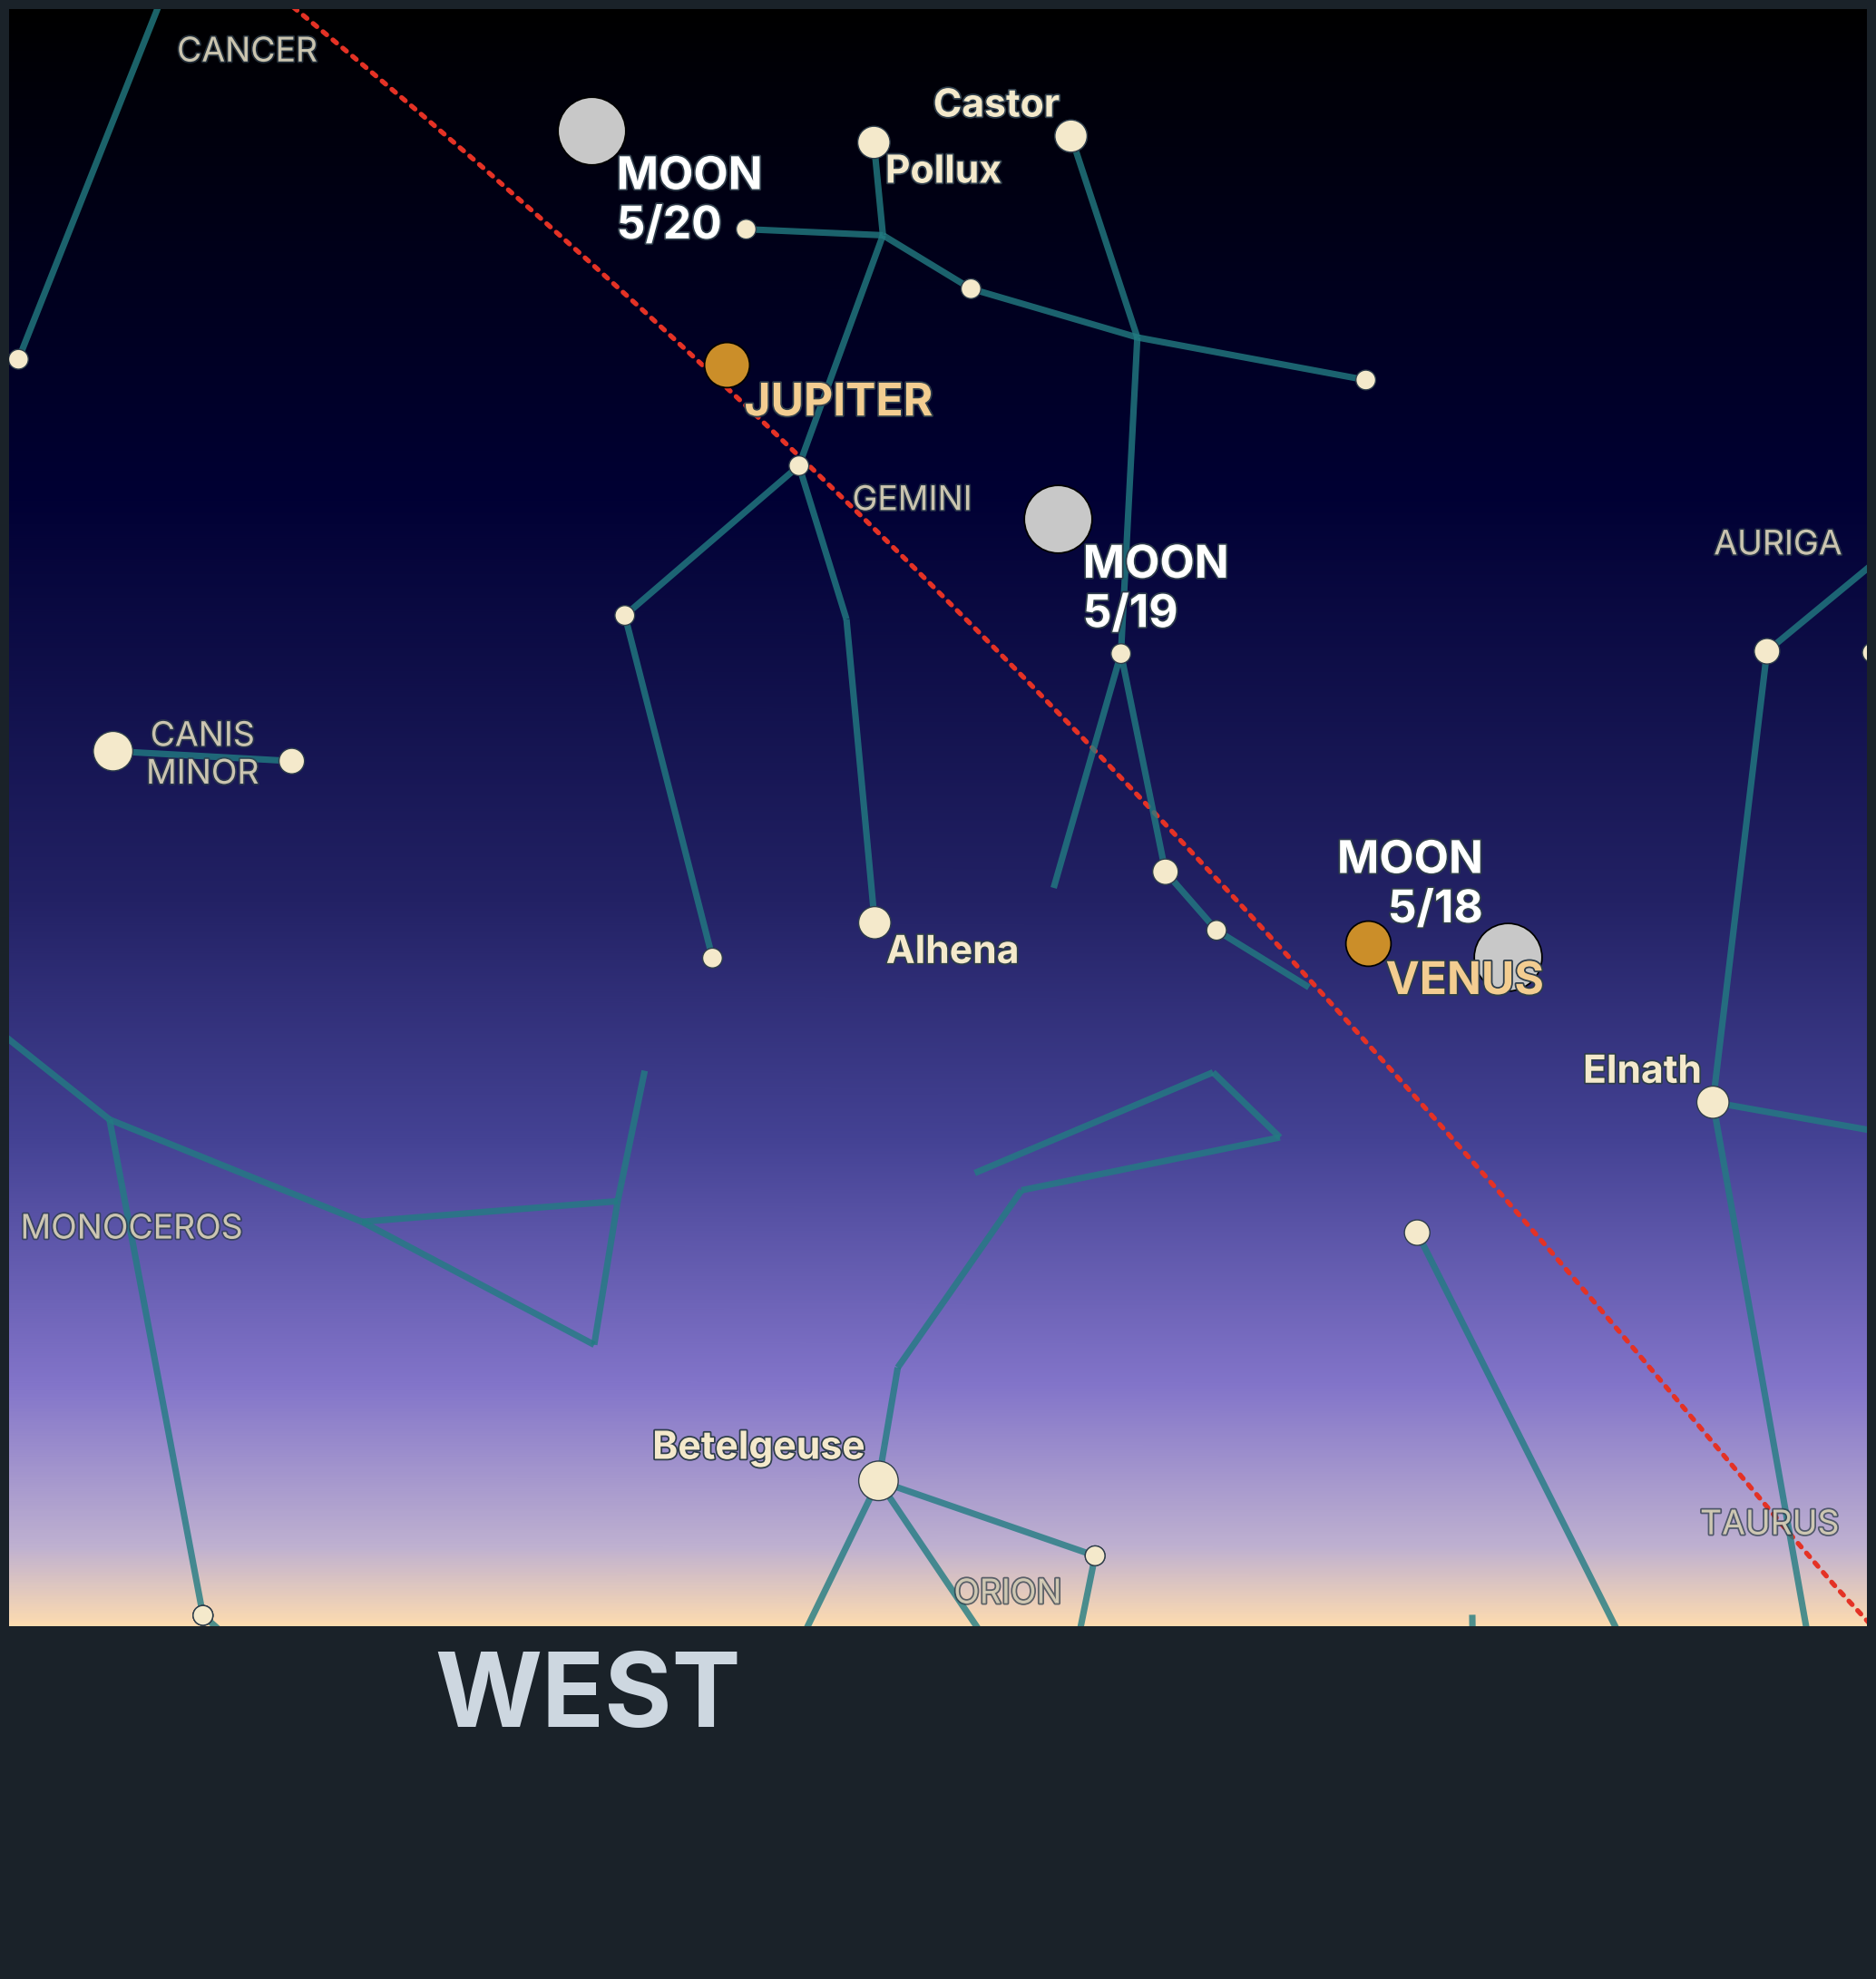

In [1]:
#!/usr/bin/env python

# Stargazing Companion Highlight, https://github.com/whitinobservatory/stargazing-companion/
# with gratitude to Steve Berardi and Starplot, https://github.com/steveberardi/starplot/blob/main/CITATION.cff
# 2026 Feb 26 - Jonathan Kemp, initial version, Whitin Observatory
# 2026 May 17 - Jonathan Kemp, release version, Whitin Observatory

# stargazing companion highlight
# core python code
# creates dark sky gradient background graphic
# python required environment
# requires at least python version 3.10
# tested with python version 3.13.5
# starplot required dependency, https://starplot.dev/installation/
# requires at least starplot version 0.19
# tested with starplot version 0.20.2
# uses starplot's zenithplot functionality

# import needed python libraries
from sys import version_info, exit
from importlib.metadata import version, PackageNotFoundError
from datetime import datetime
from zoneinfo import ZoneInfo
from starplot import HorizonPlot, Observer, Planet, Moon, callables, _
from starplot.styles import PlotStyle, ObjectStyle, MarkerStyle, MarkerSymbolEnum, FillStyleEnum, ZOrderEnum, LabelStyle, FontWeightEnum, extensions

# required dependencies check
if version_info < (3,10):
    exit("python version at least 3.10 is not installed, exiting")
try:
    if version("starplot") < "0.19":
        exit("starplot version at least 0.19 is not installed, exiting")
except PackageNotFoundError:
    exit("starplot is not installed, exiting")

# set observer timezone
tz = ZoneInfo( "America/New_York" ) # <- USER EDIT
# set observer time
# note: use day before to add preceding moon location
dt_earlier = datetime( 2026, 5, 18, 21, 0, tzinfo=tz ) # <- USER EDIT
# note: use main date for all objects
dt = datetime( 2026, 5, 19, 21, 0, tzinfo=tz ) # <- USER EDIT
# note: use day after to add following moon location
dt_later = datetime( 2026, 5, 20, 21, 0, tzinfo=tz ) # <- USER EDIT
# set observer geographic coordinates
# use day before to add preceding moon location
observer_earlier = Observer( dt=dt_earlier, lat=42.2950, lon=-71.3025 ) # <- USER EDIT
# use main date for all objects
observer = Observer( dt=dt, lat=42.2950, lon=-71.3025 ) # <- USER EDIT
# use day after to add following moon location
observer_later = Observer( dt=dt_later, lat=42.2950, lon=-71.3025 ) # <- USER EDIT

# obtain planet data of interest, omit planets not typically seen by visual observers
mercury = Planet.get( name = "Mercury", observer = observer )
venus = Planet.get( name = "Venus", observer = observer )
mars = Planet.get( name = "Mars", observer = observer )
jupiter = Planet.get( name = "Jupiter", observer = observer )
saturn = Planet.get( name = "Saturn", observer = observer )

# obtain moon data of interest
# note: use day before to add preceding moon location
moon_earlier = Moon.get( observer = observer_earlier )
# note: use main date for all objects
moon = Moon.get( observer = observer )
# note: use day after to add following moon location
moon_later = Moon.get( observer = observer_later )

# configure horizon plot, dark sky gradient background graphic, https://starplot.dev/reference-horizonplot/
p = HorizonPlot( altitude = ( 0, 39.25 ), azimuth = ( 255.9375, 300.9375 ), observer = observer, style = PlotStyle().extend( extensions.BLUE_GOLD, extensions.GRADIENT_PRE_DAWN ), resolution = 2048 )
# plot planets of interest, omit planets not typically seen by visual observers, specify color
p.marker( ra = mercury.ra, dec = mercury.dec, label = "MERCURY", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 28, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#cb8e29", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#f3cd91" } } )
p.marker( ra = venus.ra, dec = venus.dec, label = "VENUS", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 28, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#cb8e29", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#f3cd91" } } )
p.marker( ra = mars.ra, dec = mars.dec, label = "MARS", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 28, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#cb8e29", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#f3cd91" } } )
p.marker( ra = jupiter.ra, dec = jupiter.dec, label = "JUPITER", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 28, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#cb8e29", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#f3cd91" } } )
p.marker( ra=saturn.ra, dec=saturn.dec, label="SATURN", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 28, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#cb8e29", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#f3cd91" } } )
# plot moon, specify color
# note: use day before to add preceding moon location
p.marker( ra = moon_earlier.ra, dec = moon_earlier.dec, label = "MOON\n5/18", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 42, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#c8c8c8", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#ffffff" } } )
# note: use main date for all objects
p.marker( ra = moon.ra, dec = moon.dec, label = "MOON\n5/19", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 42, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#c8c8c8", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#ffffff" } } )
# note: use day after to add following moon location
p.marker( ra = moon_later.ra, dec = moon_later.dec, label = "MOON\n5/20", 
    style = { "marker": { "symbol": MarkerSymbolEnum.CIRCLE, "size": 42, "fill": FillStyleEnum.LEFT, "zorder": ZOrderEnum.LAYER_3, "alpha": 1.0, "color": "#c8c8c8", "fill": "full" },
    "label": { "font_size": 28, "font_weight": FontWeightEnum.BOLD, "offset_x": "auto", "offset_y": "auto", "font_color": "#ffffff" } } )
# plot sky elements of general interest
p.constellations()
p.constellation_labels()
p.ecliptic( num_labels = 0 )
p.stars( where = [ _.magnitude < 4.0 ] , where_labels = [ _.magnitude < 2.375 ] )
# plot special interest sky elements differently
p.stars( where = [ _.magnitude <= 3.35, _.dec >= 55.0, _.dec <= 65.0, _.ra >= 0 * 15.0, _.ra <= 2 * 15.0 ], size_fn = lambda d: callables.size_by_magnitude( d ) * 2, # <- USER EDIT
    style__marker__symbol = "star_8", style__label__offset_x = 8, style__label__offset_y = -8, style__label__border_width = 0, where_labels = [ False ] )             # <- USER EDIT
# create horizon label
p.horizon( labels = { 270: "WEST\n\n" } )
# save plot graphic
p.export( "stargazing-companion-highlight-raw.png", transparent = False, padding = 0.0 )